# Documentation du pipeline de calibration
Ce notebook réalise la calibration entre des images RGB et SWIR en utilisant une approche basée sur la généralisation d'une homographie et l'optimisation MIND. Chaque étape est expliquée ci-dessous pour faciliter la compréhension et la réutilisation.

## 1. Importation des librairies
Les librairies nécessaires sont importées pour le traitement d'images, l'optimisation, et l'utilisation du modèle RoMa.

In [1]:
# Importation des librairies nécessaires pour le traitement d'images, l'optimisation et la visualisation
import os
import re
import json
import random
from dataclasses import dataclass
from typing import List, Tuple, Dict

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt

from PIL import Image
from scipy.ndimage import gaussian_filter
from scipy.optimize import minimize
from sklearn.model_selection import KFold

from romatch import roma_outdoor

# Vérifiez que toutes les librairies sont bien installées dans votre environnement Python

## 2. Définition de la configuration
La classe `Config` centralise tous les paramètres du pipeline : chemins des dossiers, paramètres de RoMa, homographie, MIND, optimisation, etc.
**Commentaire :** Modifiez ces paramètres selon vos données ou besoins.

In [14]:
# Définition de la configuration du pipeline
@dataclass
class Config:
    # Chemin vers les dossiers d'images RGB et SWIR
    rgb_dir: str = r"C:\Users\karou\Downloads\Challenge\Sortie_Extraite_all\paired_images\VISIBLE"
    swir_dir: str = r"C:\Users\karou\Downloads\Challenge\Sortie_Extraite_all\paired_images\SWIR"
    out_dir: str = r"./out_generalized_h_bags_ch"  # Dossier de sortie pour les résultats
    
    # Extensions autorisées pour les images
    allowed_exts: Tuple[str, ...] = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
    
    # Paramètres du modèle RoMa
    roma_num_matches: int = 5000
    
    # Paramètres RANSAC pour l'initialisation de l'homographie
    ransac_reproj_thresh: float = 5.0
    
    # Paramètres pour le recadrage des régions valides
    valid_threshold: int = 10
    crop_margin: int = 15
    
    # Paramètres du descripteur MIND
    mind_r: int = 1
    mind_sigma: float = 1.0
    
    # Paramètres d'optimisation et de validation croisée
    k_folds: int = 5
    random_seed: int = 0
    
    # Taille cible pour le redimensionnement des images (W,H)
    target_size: Tuple[int, int] = (1280, 1024)  # (W,H)
    
    # Nombre maximal d'itérations pour l'optimiseur
    opt_maxiter: int = 80
    
# Initialisation de la configuration
cfg = Config()
os.makedirs(cfg.out_dir, exist_ok=True)

# Fixer les graines pour la reproductibilité
random.seed(cfg.random_seed)
np.random.seed(cfg.random_seed)
torch.manual_seed(cfg.random_seed)


## 3. Pairing des images par timestamp
Les fonctions permettent d'associer les images RGB et SWIR selon leur timestamp pour garantir une correspondance temporelle.
**Commentaire :** Vérifiez que vos fichiers contiennent bien les timestamps attendus.

In [15]:
# Fonctions utilitaires pour lister les images et associer les paires RGB/SWIR par timestamp
import os, re
from typing import List, Tuple, Optional

TS_RE = re.compile(r"seq_\d+_ts_(\d+)_(\d+)")

def list_images(folder: str, exts) -> List[str]:
    # Liste tous les fichiers d'un dossier avec les extensions autorisées
    files = []
    for fn in os.listdir(folder):
        if os.path.splitext(fn)[1].lower() in exts:
            files.append(os.path.join(folder, fn))
    files.sort()
    return files

def extract_timestamp_ns(path: str) -> Optional[int]:
    """
    Extrait le timestamp en nanosecondes du nom de fichier.
    Ex: seq_000431_ts_1768231621_235847986.tiff -> int ns
    """
    name = os.path.splitext(os.path.basename(path))[0]
    m = TS_RE.search(name)
    if not m:
        return None
    secs = int(m.group(1))
    nsecs = int(m.group(2))
    return secs * 1_000_000_000 + nsecs

def build_pairs_by_timestamp(
    rgb_dir: str,
    swir_dir: str,
    exts,
    max_diff_ms: float = 20.0,
 ) -> List[Tuple[str, str]]:
    # Associe les images RGB et SWIR ayant des timestamps proches (< max_diff_ms)
    rgb_files = list_images(rgb_dir, exts)
    swir_files = list_images(swir_dir, exts)

    rgb_ts = [(extract_timestamp_ns(p), p) for p in rgb_files]
    swir_ts = [(extract_timestamp_ns(p), p) for p in swir_files]

    rgb_ts = [(t, p) for (t, p) in rgb_ts if t is not None]
    swir_ts = [(t, p) for (t, p) in swir_ts if t is not None]

    rgb_ts.sort(key=lambda x: x[0])
    swir_ts.sort(key=lambda x: x[0])

    max_diff_ns = int(max_diff_ms * 1e6)

    # Pour éviter qu’un même RGB soit utilisé plusieurs fois:
    # on garde pour chaque RGB le SWIR le plus proche.
    best_by_rgb = {}  # rgb_path -> (diff_ns, swir_path)

    for ts_s, s_path in swir_ts:
        best_rgb = None
        best_diff = None

        # scan linéaire (ok si datasets pas énormes)
        for ts_r, r_path in rgb_ts:
            diff = abs(ts_s - ts_r)
            if diff <= max_diff_ns and (best_diff is None or diff < best_diff):
                best_diff = diff
                best_rgb = r_path
            elif ts_r > ts_s + max_diff_ns:
                break

        if best_rgb is None:
            continue

        prev = best_by_rgb.get(best_rgb)
        if prev is None or best_diff < prev[0]:
            best_by_rgb[best_rgb] = (best_diff, s_path)

    pairs = [(rgb_path, swir_path) for (rgb_path, (d, swir_path)) in best_by_rgb.items()]

    # tri par timestamp RGB pour garder un ordre stable
    pairs.sort(key=lambda pr: extract_timestamp_ns(pr[0]) or 0)

    print(f"RGB files: {len(rgb_files)} | timestamped: {len(rgb_ts)}")
    print(f"SWIR files: {len(swir_files)} | timestamped: {len(swir_ts)}")
    print(f"Matched pairs by timestamp: {len(pairs)} (tol {max_diff_ms} ms)")

    if pairs:
        d0 = abs(extract_timestamp_ns(pairs[0][0]) - extract_timestamp_ns(pairs[0][1])) / 1e6
        print("First pair:", os.path.basename(pairs[0][0]), "|", os.path.basename(pairs[0][1]), f"({d0:.3f} ms)")

    return pairs

# Construction des paires RGB/SWIR par timestamp
pairs = build_pairs_by_timestamp(cfg.rgb_dir, cfg.swir_dir, cfg.allowed_exts, max_diff_ms=20.0)

assert len(pairs) > 1, "Need at least 2 matched pairs (check filenames/timestamps)."


RGB files: 47 | timestamped: 47
SWIR files: 47 | timestamped: 47
Matched pairs by timestamp: 47 (tol 20.0 ms)
First pair: seq_000012_ts_1746520487_506737860.tiff | seq_000011_ts_1746520487_491277976.tiff (15.460 ms)


## 4. Prétraitement des images et création des masques
Chargement, redimensionnement, création de masques de validité et extraction des régions d'intérêt pour la calibration.
**Commentaire :** Ces fonctions assurent que seules les zones pertinentes sont utilisées.

In [4]:
# Fonctions de prétraitement : chargement, redimensionnement, masques de validité et recadrage
def load_and_resize(rgb_path: str, swir_path: str, target_size: Tuple[int,int]):
    # Charge et redimensionne les images RGB et SWIR à la même taille
    rgb = Image.open(rgb_path).convert("RGB")
    swir = Image.open(swir_path).convert("RGB")
    # Standardise la taille pour l'homographie généralisée
    rgb = rgb.resize(target_size, Image.BILINEAR)
    swir = swir.resize(target_size, Image.BILINEAR)
    return rgb, swir

def create_valid_mask(aligned_rgb_uint8, threshold=10):
    # Crée un masque binaire des pixels valides (> threshold)
    if aligned_rgb_uint8.ndim == 3:
        gray = cv2.cvtColor(aligned_rgb_uint8, cv2.COLOR_RGB2GRAY)
    else:
        gray = aligned_rgb_uint8
    valid = (gray > threshold).astype(np.uint8)
    kernel = np.ones((5,5), np.uint8)
    valid = cv2.morphologyEx(valid, cv2.MORPH_CLOSE, kernel)
    valid = cv2.morphologyEx(valid, cv2.MORPH_OPEN, kernel)
    return valid

def get_crop_bbox(mask_uint8):
    # Retourne la bounding box de la région valide
    coords = cv2.findNonZero(mask_uint8)
    if coords is None:
        return None
    x,y,w,h = cv2.boundingRect(coords)
    return int(x), int(y), int(w), int(h)

def crop_to_valid_region(rgb_uint8, swir_aligned_uint8, threshold=10, margin=10):
    # Recadre les images sur la région valide commune
    valid_mask = create_valid_mask(swir_aligned_uint8, threshold=threshold)

    if margin > 0:
        k = np.ones((margin*2, margin*2), np.uint8)
        valid_mask = cv2.erode(valid_mask, k, iterations=1)

    bbox = get_crop_bbox(valid_mask)
    if bbox is None:
        return None, None, None, None

    x,y,w,h = bbox
    rgb_crop = rgb_uint8[y:y+h, x:x+w]
    swir_crop = swir_aligned_uint8[y:y+h, x:x+w]
    m_crop = valid_mask[y:y+h, x:x+w]
    return rgb_crop, swir_crop, (x,y,w,h), m_crop


## 5. Calcul du descripteur MIND et de l'erreur
Le descripteur MIND est utilisé pour mesurer la similarité entre les images alignées. L'erreur MIND sert d'objectif pour l'optimisation.
**Commentaire :** Cette étape est cruciale pour l'évaluation de la qualité d'alignement.

In [5]:
# Fonctions pour le calcul du descripteur MIND et de l'erreur MIND
def compute_mind_descriptor(image_gray_uint8, r=1, sigma=1.0):
    # Calcule le descripteur MIND pour une image en niveaux de gris
    image = image_gray_uint8.astype(np.float32)

    filter_size = int(np.ceil(sigma * 3 / 2) * 2 + 1)
    gauss = cv2.getGaussianKernel(filter_size, sigma)
    gauss = gauss @ gauss.T

    if r > 0:
        y_off, x_off = np.meshgrid(range(-r, r+1), range(-r, r+1), indexing="ij")
        offsets = list(zip(x_off.flatten(), y_off.flatten()))
        offsets.remove((0,0))
    else:
        offsets = [(1,0), (-1,0), (0,1), (0,-1)]

    # variance from 4-neighborhood
    Dp = []
    for dx, dy in offsets[:4]:
        shifted = np.roll(np.roll(image, dy, axis=0), dx, axis=1)
        diff_sq = (image - shifted) ** 2
        Dp.append(cv2.filter2D(diff_sq, -1, gauss))
    Dp = np.stack(Dp, axis=-1)
    V = np.mean(Dp, axis=-1)

    V_mean = np.mean(V)
    V = np.clip(V, 0.001 * V_mean, 1000 * V_mean)
    V = np.maximum(V, 1e-10)

    mind = []
    for dx, dy in offsets:
        shifted = np.roll(np.roll(image, dy, axis=0), dx, axis=1)
        diff_sq = (image - shifted) ** 2
        fd = cv2.filter2D(diff_sq, -1, gauss)
        mind.append(np.exp(-fd / V))
    mind = np.stack(mind, axis=-1)

    max_val = np.max(mind, axis=-1, keepdims=True)
    mind = mind / np.maximum(max_val, 1e-10)
    return mind

def mind_mean_error(rgb_uint8, swir_uint8, r=1, sigma=1.0):
    # Calcule la carte d'erreur MIND entre deux images
    if rgb_uint8.ndim == 3:
        rgb_g = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2GRAY)
    else:
        rgb_g = rgb_uint8
    if swir_uint8.ndim == 3:
        swir_g = cv2.cvtColor(swir_uint8, cv2.COLOR_RGB2GRAY)
    else:
        swir_g = swir_uint8

    m1 = compute_mind_descriptor(rgb_g, r=r, sigma=sigma)
    m2 = compute_mind_descriptor(swir_g, r=r, sigma=sigma)
    err_map = np.sum((m1 - m2) ** 2, axis=-1)
    return float(np.mean(err_map)), err_map


## 6. Initialisation du modèle RoMa
Le modèle RoMa est chargé sur le GPU ou CPU pour l'estimation initiale des correspondances entre images.
**Commentaire :** Assurez-vous que le modèle est bien installé et accessible.

In [6]:
# Initialisation du modèle RoMa sur GPU ou CPU selon disponibilité
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

roma_model = roma_outdoor(device=device)


Device: cuda


c:\Users\karou\OneDrive\Bureau\Calibration\venv\Lib\site-packages\romatch\models\model_zoo\roma_models.py:49: UserWarning: Local correlation is not supported on non-Linux platforms, setting use_custom_corr to False
  warnings.warn("Local correlation is not supported on non-Linux platforms, setting use_custom_corr to False")
2026-03-08 17:36:54.026 | INFO     | romatch.models.model_zoo.roma_models:roma_model:61 - Using coarse resolution (560, 560), and upsample res (864, 864)
c:\Users\karou\OneDrive\Bureau\Calibration\venv\Lib\site-packages\romatch\models\model_zoo\roma_models.py:67: UserWarning: Local correlation is not supported on non-Linux platforms, setting use_custom_corr to False
  warnings.warn("Local correlation is not supported on non-Linux platforms, setting use_custom_corr to False")
c:\Users\karou\OneDrive\Bureau\Calibration\venv\Lib\site-packages\romatch\models\matcher.py:51: UserWarning: Local correlation is not supported on non-Linux platforms, setting use_custom_corr to

## 7. Estimation initiale des homographies par RoMa
Pour chaque paire, une homographie initiale est estimée via RoMa et RANSAC.
**Commentaire :** Les homographies non valides sont ignorées pour garantir la robustesse.

In [7]:
# Estimation initiale des homographies pour chaque paire à l'aide de RoMa et RANSAC
def estimate_h_with_roma(rgb_pil: Image.Image, swir_pil: Image.Image, roma_model, device, num_matches=5000, ransac_thresh=5.0):
    # Estime l'homographie entre une paire RGB/SWIR avec RoMa et RANSAC
    warp, certainty = roma_model.match(rgb_pil, swir_pil, device=device)
    matches, certainty = roma_model.sample(warp, certainty, num=num_matches)

    wA, hA = rgb_pil.size
    wB, hB = swir_pil.size
    kptsA, kptsB = roma_model.to_pixel_coordinates(matches, hA, wA, hB, wB)

    ptsA = kptsA.detach().cpu().numpy()
    ptsB = kptsB.detach().cpu().numpy()

    # H maps swir->rgb: ptsB -> ptsA
    H, mask = cv2.findHomography(ptsB, ptsA, cv2.RANSAC, ransac_thresh)
    return H, mask

# Calcul des homographies initiales pour toutes les paires
Hs = []
ok_pairs = []
for i, (rp, sp) in enumerate(pairs):
    rgb, swir = load_and_resize(rp, sp, cfg.target_size)
    H, mask = estimate_h_with_roma(rgb, swir, roma_model, device, cfg.roma_num_matches, cfg.ransac_reproj_thresh)
    if H is None:
        continue
    Hs.append(H)
    ok_pairs.append((rp, sp))
    print(f"[{i+1}/{len(pairs)}] OK: {os.path.basename(rp)} | inliers: {int(mask.sum()) if mask is not None else 'n/a'}")

pairs = ok_pairs
Hs = np.stack(Hs, axis=0)
print("Usable pairs:", len(pairs), "Hs:", Hs.shape)
assert len(pairs) >= 3, "Need at least 3 usable pairs to do CV reliably."


[1/77] OK: seq_000001_ts_1768231457_218427857.tiff | inliers: 3681
[2/77] OK: seq_000005_ts_1768231457_616143021.tiff | inliers: 4354
[3/77] OK: seq_000007_ts_1768231457_814874798.tiff | inliers: 3922
[4/77] OK: seq_000009_ts_1768231458_013706651.tiff | inliers: 4333
[5/77] OK: seq_000028_ts_1768231460_001623326.tiff | inliers: 4235
[6/77] OK: seq_000033_ts_1768231460_399321665.tiff | inliers: 4074
[7/77] OK: seq_000035_ts_1768231460_597920230.tiff | inliers: 4222
[8/77] OK: seq_000037_ts_1768231460_796783817.tiff | inliers: 3938
[9/77] OK: seq_000039_ts_1768231460_995547448.tiff | inliers: 3829
[10/77] OK: seq_000051_ts_1768231462_188183377.tiff | inliers: 4318
[11/77] OK: seq_000061_ts_1768231463_182201348.tiff | inliers: 4540
[12/77] OK: seq_000063_ts_1768231463_381010779.tiff | inliers: 4234
[13/77] OK: seq_000064_ts_1768231463_579593667.tiff | inliers: 4226
[14/77] OK: seq_000072_ts_1768231464_375212989.tiff | inliers: 4231
[15/77] OK: seq_000076_ts_1768231464_773018929.tiff | inl

## 8. Conversion et initialisation de l'homographie générale
Les fonctions permettent de convertir entre vecteur et matrice d'homographie. L'initialisation se fait par la médiane des homographies estimées.
**Commentaire :** Cette étape prépare l'optimisation globale.

In [8]:
# Fonctions pour convertir entre vecteur et matrice d'homographie
def vec_to_H(p):
    # Convertit un vecteur de 8 paramètres en matrice d'homographie 3x3
    p = np.asarray(p, dtype=np.float64).reshape(-1)
    assert p.size == 8
    h11,h12,h13,h21,h22,h23,h31,h32 = p.tolist()
    H = np.array([[h11,h12,h13],
                  [h21,h22,h23],
                  [h31,h32,1.0]], dtype=np.float64)
    return H

def H_to_vec(H):
    # Convertit une matrice d'homographie 3x3 en vecteur de 8 paramètres
    H = H / H[2,2]
    return np.array([H[0,0],H[0,1],H[0,2],
                     H[1,0],H[1,1],H[1,2],
                     H[2,0],H[2,1]], dtype=np.float64)

# Initialisation de l'homographie générale par la médiane des homographies estimées
H_init = np.median(Hs / Hs[:,2:3,2:3], axis=0)
H_init = H_init / H_init[2,2]
p0 = H_to_vec(H_init)
p0


array([ 1.23851431e+00,  8.89324770e-03, -1.71743111e+02,  1.46596553e-02,
        1.29525417e+00, -1.95662274e+02,  3.55214978e-06, -2.83567800e-06])

## 9. Calcul de la perte MIND pour chaque paire
La fonction calcule la perte MIND pour chaque paire d'images alignées par l'homographie candidate.
**Commentaire :** Utilisé dans l'objectif d'optimisation.

In [9]:
# Fonctions pour appliquer l'homographie et calculer la perte MIND sur une paire
def warp_swir_to_rgb(swir_uint8, H, out_size_wh):
    # Applique l'homographie H à l'image SWIR pour l'aligner sur l'image RGB
    W,Hh = out_size_wh
    warped = cv2.warpPerspective(swir_uint8, H, (int(W), int(Hh)))
    return warped

def pair_mind_loss(rgb_path, swir_path, H, cfg: Config):
    # Calcule la perte MIND pour une paire RGB/SWIR alignée par H
    rgb_pil, swir_pil = load_and_resize(rgb_path, swir_path, cfg.target_size)
    rgb = np.array(rgb_pil)
    swir = np.array(swir_pil)

    swir_aligned = warp_swir_to_rgb(swir, H, cfg.target_size)

    rgb_c, swir_c, bbox, _ = crop_to_valid_region(
        rgb, swir_aligned,
        threshold=cfg.valid_threshold,
        margin=cfg.crop_margin
    )
    if rgb_c is None:
        return 1e6  # pénalité forte si pas de recouvrement

    m, _ = mind_mean_error(rgb_c, swir_c, r=cfg.mind_r, sigma=cfg.mind_sigma)
    return m

def dataset_objective(p, train_pairs, cfg: Config, H_prior, lam):
    # Fonction objectif pour l'optimisation globale de l'homographie
    H = vec_to_H(p)
    # normalisation de l'échelle
    H = H / H[2,2]

    losses = []
    for rp, sp in train_pairs:
        losses.append(pair_mind_loss(rp, sp, H, cfg))
    data_term = float(np.mean(losses))

    # régularisation vers l'homographie moyenne pour éviter les déformations
    diff = (H - H_prior)
    reg_term = float(np.mean(diff*diff))

    return data_term + lam * reg_term


## 10. Optimisation par validation croisée (CV)
Optimisation de l'homographie générale par validation croisée pour choisir la meilleure régularisation.
**Commentaire :** Permet d'éviter le sur-apprentissage et d'obtenir une homographie robuste.

In [ ]:
# Optimisation de l'homographie générale par validation croisée
kf = KFold(n_splits=cfg.k_folds, shuffle=True, random_state=cfg.random_seed)

# Grille de recherche pour la régularisation
lam_grid = [1e-3, 1e-2, 1e-1, 1.0]

# Homographie moyenne utilisée comme prior/stabilisateur
H_prior = np.mean(Hs / Hs[:,2:3,2:3], axis=0)
H_prior = H_prior / H_prior[2,2]

cv_results = []
pair_indices = np.arange(len(pairs))

for lam in lam_grid:
    fold_vals = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(pair_indices), 1):
        train_pairs = [pairs[i] for i in tr_idx]
        val_pairs   = [pairs[i] for i in va_idx]

        res = minimize(
            fun=lambda p: dataset_objective(p, train_pairs, cfg, H_prior, lam),
            x0=p0,
            method="Powell",
            options=dict(maxiter=cfg.opt_maxiter, disp=True),
        )

        H_fold = vec_to_H(res.x)
        H_fold = H_fold / H_fold[2,2]

        # Calcul de la perte de validation
        vlosses = [pair_mind_loss(rp, sp, H_fold, cfg) for rp, sp in val_pairs]
        fold_val = float(np.mean(vlosses))
        fold_vals.append(fold_val)

        print(f"lam={lam:g} | fold {fold}/{cfg.k_folds} | val MIND={fold_val:.6f} | iters={res.nit}")

    cv_mean = float(np.mean(fold_vals))
    cv_std  = float(np.std(fold_vals))
    cv_results.append((lam, cv_mean, cv_std))
    print(f"lam={lam:g} | CV mean={cv_mean:.6f} ± {cv_std:.6f}\n")

# Sélection du meilleur paramètre de régularisation
best_lam, best_mean, best_std = sorted(cv_results, key=lambda x: x[1])[0]
best_lam, best_mean, best_std


## 11. Optimisation finale de l'homographie générale
Optimisation sur l'ensemble des paires avec le meilleur paramètre de régularisation.
**Commentaire :** Résultat final utilisé pour l'alignement.

In [11]:
best_lam = 1e-3  # à fixer selon les résultats de CV
# Homographie moyenne utilisée comme prior/stabilisateur
H_prior = np.mean(Hs / Hs[:,2:3,2:3], axis=0)
H_prior = H_prior / H_prior[2,2]
# Optimisation finale de l'homographie générale sur toutes les paires
res_final = minimize(
    fun=lambda p: dataset_objective(p, pairs, cfg, H_prior, best_lam),
    x0=p0,
    method="Powell",
    options=dict(maxiter=max(cfg.opt_maxiter, 120), disp=True),
)

H_general = vec_to_H(res_final.x)
H_general = H_general / H_general[2,2]
H_general


Optimization terminated successfully.
         Current function value: 0.720908
         Iterations: 7
         Function evaluations: 1515


array([[ 1.24134705e+00,  4.13005514e-03, -1.70529886e+02],
       [ 1.57798783e-02,  1.29435194e+00, -1.95377217e+02],
       [ 3.67555661e-06, -5.34703937e-07,  1.00000000e+00]])

## 12. Sauvegarde de l'homographie générale
La matrice d'homographie finale est sauvegardée au format `.npy` et `.json` pour une utilisation ultérieure.
**Commentaire :** Vérifiez les chemins de sauvegarde selon vos besoins.

In [12]:
# Sauvegarde de la matrice d'homographie généralisée
H_path_npy = os.path.join(cfg.out_dir, "H_general.npy")
H_path_json = os.path.join(cfg.out_dir, "H_general.json")

np.save(H_path_npy, H_general)

with open(H_path_json, "w", encoding="utf-8") as f:
    json.dump(H_general.tolist(), f, indent=2)

print("Saved:", H_path_npy)
print("Saved:", H_path_json)


Saved: ./out_generalized_h_bags_1280x1024\H_general.npy
Saved: ./out_generalized_h_bags_1280x1024\H_general.json


## 13. Visualisation des résultats
Chargement de l'homographie, application sur une paire d'exemple, visualisation des résultats et de la fusion HSV.
**Commentaire :** Permet d'évaluer visuellement la qualité de l'alignement.

Loaded H_general shape: (3, 3)
[[4.09169676e-01 8.88484472e-03 1.92723245e+02]
 [1.34230205e-02 3.90728344e-01 1.54271619e+02]
 [4.19143527e-05 1.13831343e-05 1.00000000e+00]]
Sample: seq_000097_ts_1746520495_849477321.tiff


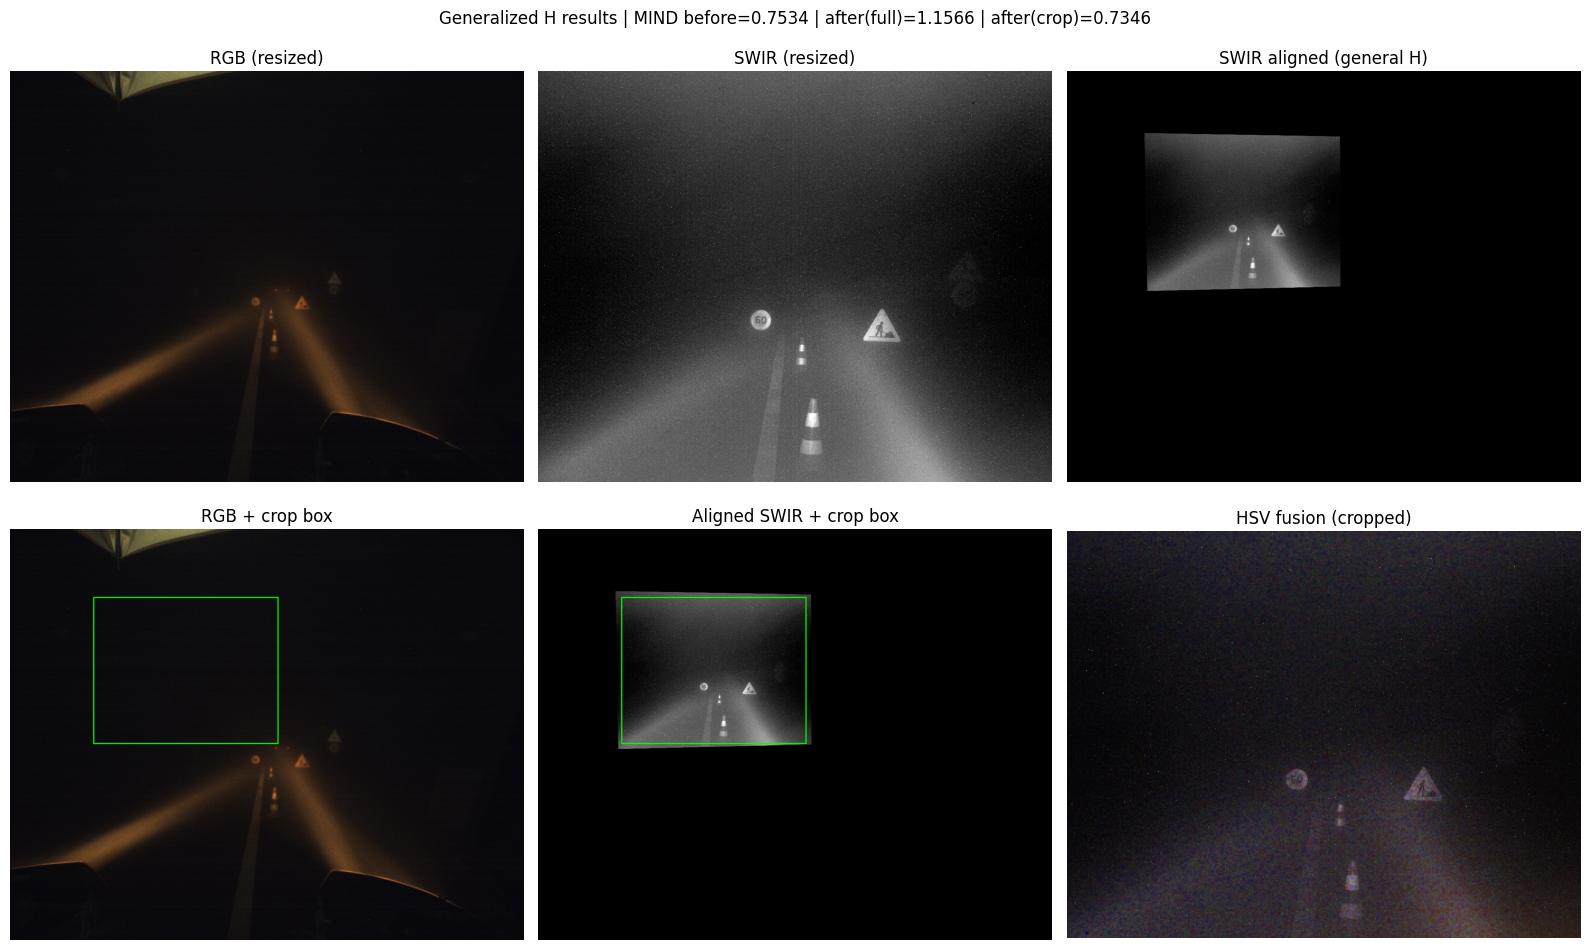

(np.float64(-0.5), np.float64(458.5), np.float64(363.5), np.float64(-0.5))

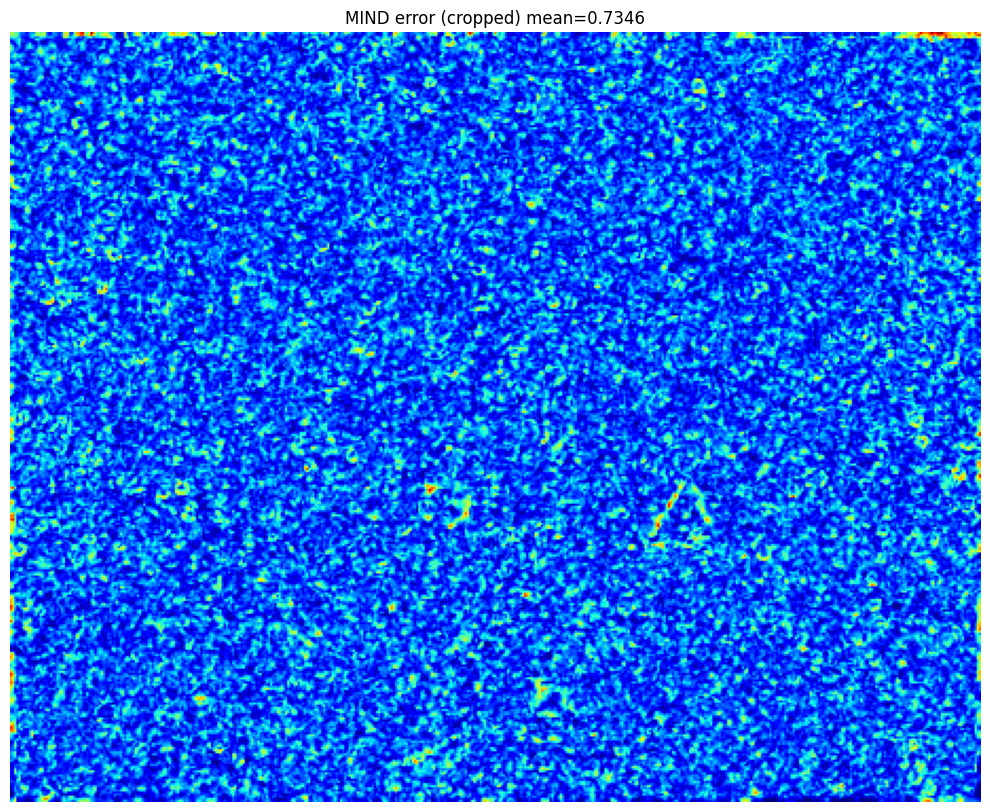

In [13]:
H_path = os.path.join("out_generalized_h_bags_challenge", "H_general.npy")
H_general = np.load(H_path)          # Charge la matrice d'homographie 3x3
H_general = H_general / H_general[2,2]  # Normalise l'échelle
print("Loaded H_general shape:", H_general.shape)
print(H_general)
      

# Choix d'une paire d'exemple (modifiable)
#sample_idx = min(0, len(pairs)-1)  
#rgb_path, swir_path = pairs[60] # change this index si besoin

# Exemple de chemins d'images (à adapter selon votre dataset)
rgb_path  = r"C:\Users\karou\Downloads\Challenge\Sortie_Extraite_all\paired_images\VISIBLE\seq_000097_ts_1746520495_849477321.tiff" 
swir_path = r"C:\Users\karou\Downloads\Challenge\Sortie_Extraite_all\paired_images\SWIR\seq_000096_ts_1746520495_849369523.tiff"

print("Sample:", os.path.basename(rgb_path))

rgb_pil, swir_pil = load_and_resize(rgb_path, swir_path, cfg.target_size)
rgb = np.array(rgb_pil)
swir = np.array(swir_pil)       

swir_aligned = warp_swir_to_rgb(swir, H_general, cfg.target_size)

rgb_c, swir_c, bbox, _ = crop_to_valid_region(
    rgb, swir_aligned, threshold=cfg.valid_threshold, margin=cfg.crop_margin
)
assert bbox is not None, "No overlap found for visualization."

x,y,w,h = map(int, bbox)

m_before, err_before = mind_mean_error(rgb, swir, r=cfg.mind_r, sigma=cfg.mind_sigma)
m_after_full, err_after_full = mind_mean_error(rgb, swir_aligned, r=cfg.mind_r, sigma=cfg.mind_sigma)
m_after_crop, err_after_crop = mind_mean_error(rgb_c, swir_c, r=cfg.mind_r, sigma=cfg.mind_sigma)

# Fusion HSV simple sur la région recadrée
swir_intensity_c = cv2.cvtColor(swir_c, cv2.COLOR_RGB2GRAY)
hsv_rgb = cv2.cvtColor(rgb_c, cv2.COLOR_RGB2HSV)
h_ch, s_ch, v_ch = cv2.split(hsv_rgb)
v_new = cv2.addWeighted(v_ch, 0.5, swir_intensity_c, 0.5, 0)
fused_hsv = cv2.cvtColor(cv2.merge((h_ch, s_ch, v_new)), cv2.COLOR_HSV2RGB)

# Dessine la boîte de recadrage sur les images
rgb_box = rgb.copy()
cv2.rectangle(rgb_box, (x,y), (x+w, y+h), (0,255,0), 2) 
swir_aligned_box = swir_aligned.copy()
cv2.rectangle(swir_aligned_box, (x,y), (x+w, y+h), (0,255,0), 2)

plt.figure(figsize=(16, 10))
plt.suptitle(
    f"Generalized H results | MIND before={m_before:.4f} | after(full)={m_after_full:.4f} | after(crop)={m_after_crop:.4f}",
    fontsize=12
)

plt.subplot(2,3,1); plt.imshow(rgb); plt.title("RGB (resized)"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(swir); plt.title("SWIR (resized)"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(swir_aligned); plt.title("SWIR aligned (general H)"); plt.axis("off")

plt.subplot(2,3,4); plt.imshow(rgb_box); plt.title("RGB + crop box"); plt.axis("off")
plt.subplot(2,3,5); plt.imshow(swir_aligned_box); plt.title("Aligned SWIR + crop box"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(fused_hsv); plt.title("HSV fusion (cropped)"); plt.axis("off")
plt.tight_layout()
plt.show()

# Carte d'erreur MIND sur la région recadrée
plt.figure(figsize=(14,10))
plt.imshow(err_after_crop, cmap="jet")
plt.title(f"MIND error (cropped) mean={m_after_crop:.4f}")
plt.axis("off")